# Task 1 - Step 6: Representation analysis

1. **Cosine stability** `I_T = mean_i cos(f(x_i), f(T(x_i)))` for grayscale, cue conflict, translation and
   patch shuffle (hue rotation added as an extra row). For a cue conflict, the clean counterpart is its
   **content** image.
2. **Prediction vs representation**: does the representation move when the prediction stays, and vice
   versa? Plus CLIP zero-shot vs CLIP's trained head on the same features.
3. **Informative cue-conflict examples** with every system's prediction.
4. **t-SNE** per backbone, fitted once on the combined clean + transformed features. Colour = ground-truth
   class (for cue conflicts: the content/shape class), marker = condition.

In [1]:
# ---- Common header (identical in every Task 1 notebook) ----
import json, random, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

# Locate the task1/ folder no matter where Jupyter was launched from.
ROOT = Path.cwd()
if not (ROOT / "configs").exists() and (ROOT / "task1" / "configs").exists():
    ROOT = ROOT / "task1"

CFG = json.loads((ROOT / "configs" / "task1_config.json").read_text())
SEED = CFG["seed"]

# Small, git-tracked outputs -> results/.  Large tensors/weights/raw data -> cache/ and data/ (git-ignored).
RES = ROOT / "results"
CACHE = ROOT / "cache"
DATA = ROOT / "data"
for p in [RES / "subset", RES / "cue_conflicts", RES / "tables", RES / "figures",
          CACHE / "sets", CACHE / "features", CACHE / "heads", CACHE / "weights", DATA]:
    p.mkdir(parents=True, exist_ok=True)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"


def set_seed(seed=SEED):
    """Fix every RNG we use so reruns reproduce the same numbers."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


set_seed()
print("ROOT:", ROOT, "| device:", DEVICE, "| seed:", SEED)

ROOT: C:\Users\afifh\Desktop\ATML\PA1\task1 | device: cuda | seed: 6304


In [2]:
import torch.nn.functional as F
from sklearn.manifold import TSNE
from sklearn.metrics import roc_auc_score

plt.rcParams.update({"font.size": 11, "axes.titlesize": 12, "axes.labelsize": 11, "legend.fontsize": 9,
                     "figure.dpi": 100, "savefig.dpi": 150})
TAB, FIG = RES / "tables", RES / "figures"


def savefig(fig, stem):
    """Save every figure as PNG + PDF under results/figures (never only displayed)."""
    fig.savefig(FIG / f"{stem}.png", bbox_inches="tight")
    fig.savefig(FIG / f"{stem}.pdf", bbox_inches="tight")
    print("saved figure", stem)

B = torch.load(CACHE / "outputs" / "task1_outputs.pt")
FE = torch.load(CACHE / "features" / "task1_eval_features.pt")["features"]
CLASSES, SYSTEMS, P, BACKBONE_OF = B["classes"], B["systems"], B["probs"], B["backbone_of"]
BACKBONES = ["resnet50", "vit_b16", "clip_vitb32"]
y = B["labels"].numpy()
cc = B["cue_conflict"]
content_idx = cc["content_idx"].numpy()
tr = CFG["translation"]
if B["smoke"]:
    print("WARNING: these are SMOKE-mode outputs - do not report these numbers")


def pred(system, name):
    return P[system][name].argmax(1).numpy()


def clean_ref(name):
    """Index of the clean counterpart of every image in set `name`."""
    return content_idx if name == "cue_conflict" else np.arange(len(y))


def cosines(bb, name):
    return F.cosine_similarity(FE[bb]["clean"][clean_ref(name)], FE[bb][name], dim=1).numpy()


# Interventions analysed; each translation displacement pools its 4 directions.
GROUPS = {"grayscale": ["grayscale"], "hue_rotate": ["hue_rotate"], "patch_shuffle": ["patch_shuffle"],
          "cue_conflict": ["cue_conflict"]}
for delta in tr["displacements"]:
    GROUPS[f"translate_{delta}"] = [f"translate_{d}_{delta}" for d in tr["directions"]]

## 6.1 Cosine stability per backbone

In [3]:
rows = []
for bb in BACKBONES:
    for g, names in GROUPS.items():
        c = np.concatenate([cosines(bb, n) for n in names])
        per_dir = [float(cosines(bb, n).mean()) for n in names]
        rows.append({"backbone": bb, "intervention": g, "I_T": float(c.mean()), "std": float(c.std()),
                     "median": float(np.median(c)), "p05": float(np.percentile(c, 5)), "min": float(c.min()),
                     "n_pairs": int(len(c)), "I_T_per_direction": json.dumps(per_dir) if len(names) > 1 else ""})
SIM = pd.DataFrame(rows)
SIM.to_csv(TAB / "task1_representation_similarity.csv", index=False)
SIM.pivot(index="intervention", columns="backbone", values="I_T").loc[list(GROUPS)].round(4)

backbone,clip_vitb32,resnet50,vit_b16
intervention,,,
grayscale,0.8941,0.7867,0.7368
hue_rotate,0.8960,0.8159,0.6871
patch_shuffle,0.7327,0.7150,0.6524
cue_conflict,0.6819,0.2484,0.2308
translate_8,0.9806,0.9681,0.9473
translate_16,0.9680,0.9531,0.9745
translate_32,0.9697,0.9337,0.9431


saved figure task1_representation_similarity


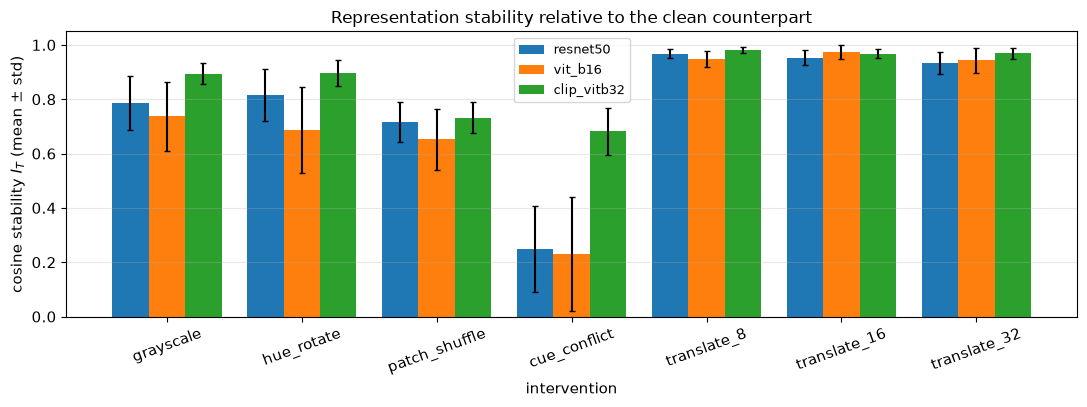

In [4]:
fig, ax = plt.subplots(figsize=(11, 4.2))
w = .27
order = list(GROUPS)
for i, bb in enumerate(BACKBONES):
    s = SIM[SIM.backbone == bb].set_index("intervention").loc[order]
    ax.bar(np.arange(len(order)) + (i - 1) * w, s.I_T, w, yerr=s["std"], capsize=2, label=bb)
ax.set_xticks(np.arange(len(order))); ax.set_xticklabels(order, rotation=20)
ax.set_ylabel("cosine stability $I_T$ (mean ± std)"); ax.set_xlabel("intervention"); ax.set_ylim(0, 1.05)
ax.legend(); ax.grid(axis="y", alpha=.3)
ax.set_title("Representation stability relative to the clean counterpart")
plt.tight_layout(); savefig(fig, "task1_representation_similarity"); plt.show()

## 6.2 Prediction vs representation

For each system and intervention: prediction consistency, `I_T` split by whether the prediction was
unchanged ("stable") or changed, and the AUROC of per-image cosine for separating stable from changed
predictions (0.5 = the representation shift says nothing about whether the decision flips).
For cue conflicts, "stable" means the same prediction as on the clean content image.

In [5]:
def stable_mask(s, name):
    return pred(s, name) == pred(s, "clean")[clean_ref(name)]


rows = []
for s in SYSTEMS:
    bb = BACKBONE_OF[s]
    for g, names in GROUPS.items():
        c = np.concatenate([cosines(bb, n) for n in names])
        st = np.concatenate([stable_mask(s, n) for n in names])
        both = st.any() and (~st).any()
        rows.append({"system": s, "backbone": bb, "intervention": g, "consistency": float(st.mean()), "I_T": float(c.mean()),
                     "I_T_pred_stable": float(c[st].mean()) if st.any() else None,
                     "I_T_pred_changed": float(c[~st].mean()) if (~st).any() else None,
                     "n_stable": int(st.sum()), "n_changed": int((~st).sum()),
                     "auroc_cos_predicts_stable": float(roc_auc_score(st, c)) if both else None})
PVR = pd.DataFrame(rows)
PVR.to_csv(TAB / "task1_prediction_vs_representation.csv", index=False)
PVR.round(3)

,system,backbone,intervention,consistency,I_T,I_T_pred_stable,I_T_pred_changed,n_stable,n_changed,auroc_cos_predicts_stable
0,resnet50_head,resnet50,grayscale,0.952,0.787,0.790,0.713,476,24,0.683
1,resnet50_head,resnet50,hue_rotate,0.948,0.816,0.819,0.757,474,26,0.671
2,resnet50_head,resnet50,patch_shuffle,0.894,0.715,0.716,0.704,447,53,0.529
3,resnet50_head,resnet50,cue_conflict,0.276,0.248,0.406,0.188,69,181,0.852
4,resnet50_head,resnet50,translate_8,0.986,0.968,0.968,0.952,1973,27,0.696
5,resnet50_head,resnet50,translate_16,0.988,0.953,0.953,0.938,1977,23,0.660
6,resnet50_head,resnet50,translate_32,0.978,0.934,0.934,0.905,1956,44,0.717
7,vit_b16_head,vit_b16,grayscale,0.976,0.737,0.740,0.614,488,12,0.761
8,vit_b16_head,vit_b16,hue_rotate,0.958,0.687,0.695,0.508,479,21,0.819
9,vit_b16_head,vit_b16,patch_shuffle,0.938,0.652,0.657,0.583,469,31,0.678


In [6]:
# Informative mismatches (deterministic): stable prediction with the LOWEST cosine, changed prediction with the HIGHEST.
rows = []
for s in ["resnet50_head", "vit_b16_head", "clip_head", "clip_zeroshot"]:
    bb = BACKBONE_OF[s]
    for name in ["grayscale", "patch_shuffle", "translate_right_32", "cue_conflict"]:
        c, st = cosines(bb, name), stable_mask(s, name)
        ref = clean_ref(name)
        for kind, idx in [("stable_pred_low_cos", np.where(st)[0][np.argsort(c[st])][:3]),
                          ("changed_pred_high_cos", np.where(~st)[0][np.argsort(-c[~st])][:3])]:
            for i in idx:
                rows.append({"system": s, "intervention": name, "kind": kind, "image_index": int(i),
                             "clean_index": int(ref[i]), "true_class": CLASSES[y[ref[i]]], "cosine": float(c[i]),
                             "clean_pred": CLASSES[pred(s, "clean")[ref[i]]], "transformed_pred": CLASSES[pred(s, name)[i]],
                             "transformed_conf": float(P[s][name][i].max())})
MISMATCH = pd.DataFrame(rows)
MISMATCH.to_csv(TAB / "task1_pred_repr_mismatch_examples.csv", index=False)
MISMATCH.head(12)

,system,intervention,kind,image_index,clean_index,true_class,cosine,clean_pred,transformed_pred,transformed_conf
0,resnet50_head,grayscale,stable_pred_low_cos,152,152,bird,0.433139,bird,bird,0.999360
1,resnet50_head,grayscale,stable_pred_low_cos,87,87,bird,0.436157,bird,bird,0.968211
2,resnet50_head,grayscale,stable_pred_low_cos,339,339,horse,0.438714,horse,horse,0.922073
3,resnet50_head,grayscale,changed_pred_high_cos,446,446,car,0.934446,horse,car,0.352828
4,resnet50_head,grayscale,changed_pred_high_cos,106,106,monkey,0.871683,monkey,deer,0.460987
5,resnet50_head,grayscale,changed_pred_high_cos,259,259,horse,0.850317,horse,deer,0.514725
6,resnet50_head,patch_shuffle,stable_pred_low_cos,80,80,cat,0.441663,cat,cat,0.937251
7,resnet50_head,patch_shuffle,stable_pred_low_cos,177,177,truck,0.488650,truck,truck,0.628620
8,resnet50_head,patch_shuffle,stable_pred_low_cos,453,453,cat,0.513119,cat,cat,0.987395
9,resnet50_head,patch_shuffle,changed_pred_high_cos,109,109,truck,0.845427,truck,deer,0.289926


saved figure task1_prediction_vs_representation


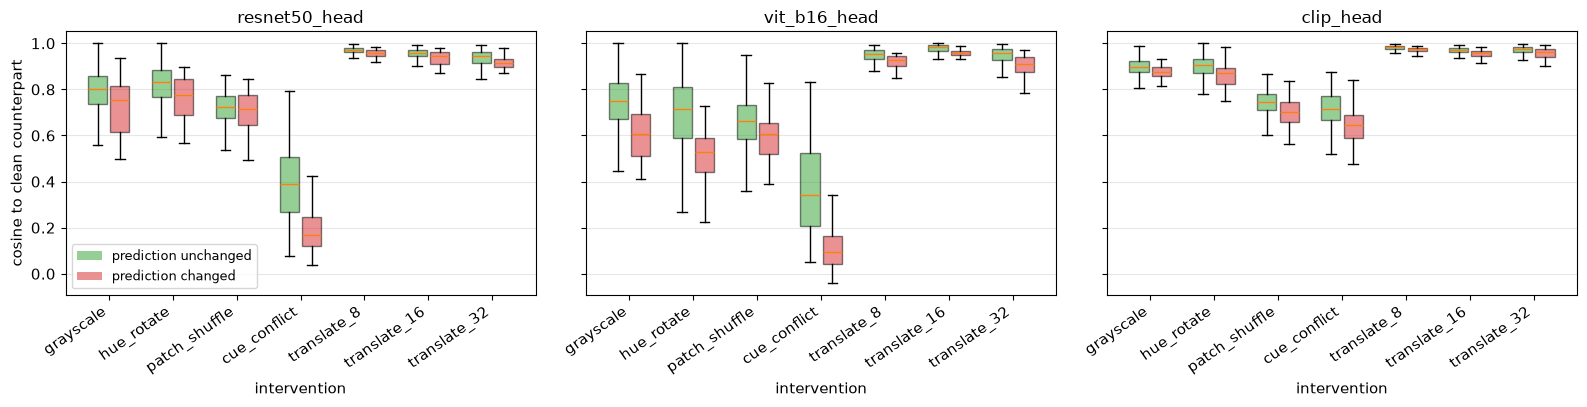

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.2), sharey=True)
order = list(GROUPS)
for ax, s in zip(axes, ["resnet50_head", "vit_b16_head", "clip_head"]):
    bb = BACKBONE_OF[s]
    data, pos, cols = [], [], []
    for j, g in enumerate(order):
        c = np.concatenate([cosines(bb, n) for n in GROUPS[g]])
        st = np.concatenate([stable_mask(s, n) for n in GROUPS[g]])
        for k, (m, col) in enumerate([(st, "tab:green"), (~st, "tab:red")]):
            if m.any():
                data.append(c[m]); pos.append(j + (k - .5) * .35); cols.append(col)
    bp = ax.boxplot(data, positions=pos, widths=.3, patch_artist=True, showfliers=False)
    for patch, col in zip(bp["boxes"], cols):
        patch.set_facecolor(col); patch.set_alpha(.5)
    ax.set_xticks(range(len(order))); ax.set_xticklabels(order, rotation=35, ha="right")
    ax.set_title(s); ax.set_xlabel("intervention"); ax.grid(axis="y", alpha=.3)
axes[0].set_ylabel("cosine to clean counterpart")
axes[0].legend([plt.Rectangle((0, 0), 1, 1, fc="tab:green", alpha=.5), plt.Rectangle((0, 0), 1, 1, fc="tab:red", alpha=.5)],
               ["prediction unchanged", "prediction changed"], loc="lower left")
plt.tight_layout(); savefig(fig, "task1_prediction_vs_representation"); plt.show()

### CLIP zero-shot vs CLIP trained head (same frozen features)

In [8]:
rows = []
sh, tx = cc["shape_label"].numpy(), cc["texture_label"].numpy()
for name in B["set_names"]:
    ph, pz = pred("clip_head", name), pred("clip_zeroshot", name)
    row = {"set": name, "agreement_head_vs_zeroshot": float((ph == pz).mean())}
    if name == "cue_conflict":
        for tag, p in [("head", ph), ("zeroshot", pz)]:
            ns, nt = int((p == sh).sum()), int((p == tx).sum())
            row[f"{tag}_shape_bias_pct"] = 100 * ns / (ns + nt) if ns + nt else None
            row[f"{tag}_coverage_pct"] = 100 * (ns + nt) / len(p)
    else:
        row["head_acc"], row["zeroshot_acc"] = float((ph == y).mean()), float((pz == y).mean())
        row["head_consistency"] = float((ph == pred("clip_head", "clean")).mean())
        row["zeroshot_consistency"] = float((pz == pred("clip_zeroshot", "clean")).mean())
    rows.append(row)
ZS = pd.DataFrame(rows)
ZS.to_csv(TAB / "task1_clip_zeroshot_vs_head.csv", index=False)
ZS.round(4)

,set,agreement_head_vs_zeroshot,head_acc,zeroshot_acc,head_consistency,zeroshot_consistency,head_shape_bias_pct,head_coverage_pct,zeroshot_shape_bias_pct,zeroshot_coverage_pct
0,clean,0.942,0.968,0.936,1.000,1.000,NaN,NaN,NaN,NaN
1,grayscale,0.938,0.928,0.908,0.938,0.922,NaN,NaN,NaN,NaN
2,hue_rotate,0.930,0.918,0.916,0.930,0.930,NaN,NaN,NaN,NaN
3,patch_shuffle,0.836,0.796,0.798,0.786,0.798,NaN,NaN,NaN,NaN
4,cue_conflict,0.644,NaN,NaN,NaN,NaN,88.6525,56.4,87.5912,54.8
5,translate_right_8,0.958,0.960,0.950,0.972,0.956,NaN,NaN,NaN,NaN
6,translate_left_8,0.956,0.952,0.942,0.964,0.956,NaN,NaN,NaN,NaN
7,translate_down_8,0.958,0.966,0.950,0.968,0.958,NaN,NaN,NaN,NaN
8,translate_up_8,0.946,0.964,0.948,0.970,0.968,NaN,NaN,NaN,NaN
9,translate_right_16,0.954,0.954,0.944,0.962,0.954,NaN,NaN,NaN,NaN


## 6.3 Informative cue-conflict agreements, disagreements and failures

All retained conflicts are listed with every system's prediction. The figure shows the first examples
(in stored order) of four categories: all systems follow shape, all follow texture, systems disagree
(some shape, some texture), and all systems predict another class. This is illustration only; conflict
retention was decided in notebook 03 without any model.

In [9]:
meta = pd.read_csv(RES / "cue_conflicts" / "metadata.csv")
kept = meta[meta["keep"]].reset_index(drop=True)
ex = kept[["pair", "direction", "shape_class", "texture_class", "content_idx", "style_idx"]].copy()
cats = {}
for s in SYSTEMS:
    p = pred(s, "cue_conflict")
    cats[s] = np.where(p == sh, "shape", np.where(p == tx, "texture", "other"))
    ex[f"{s}_pred"] = [CLASSES[k] for k in p]
    ex[f"{s}_conf"] = P[s]["cue_conflict"].max(1).values.numpy()
    ex[f"{s}_decision"] = cats[s]
C = np.stack([cats[s] for s in SYSTEMS], 1)
ex["category"] = np.select([(C == "shape").all(1), (C == "texture").all(1), (C == "shape").any(1) & (C == "texture").any(1),
                            (C == "other").all(1)], ["all_shape", "all_texture", "disagree_shape_vs_texture", "all_other"], "mixed_other")
ex.to_csv(TAB / "task1_cue_conflict_examples.csv", index=False)
ex.category.value_counts()

category
mixed_other                  109
disagree_shape_vs_texture     49
all_other                     46
all_shape                     44
all_texture                    2
Name: count, dtype: int64

saved figure task1_cue_conflict_examples


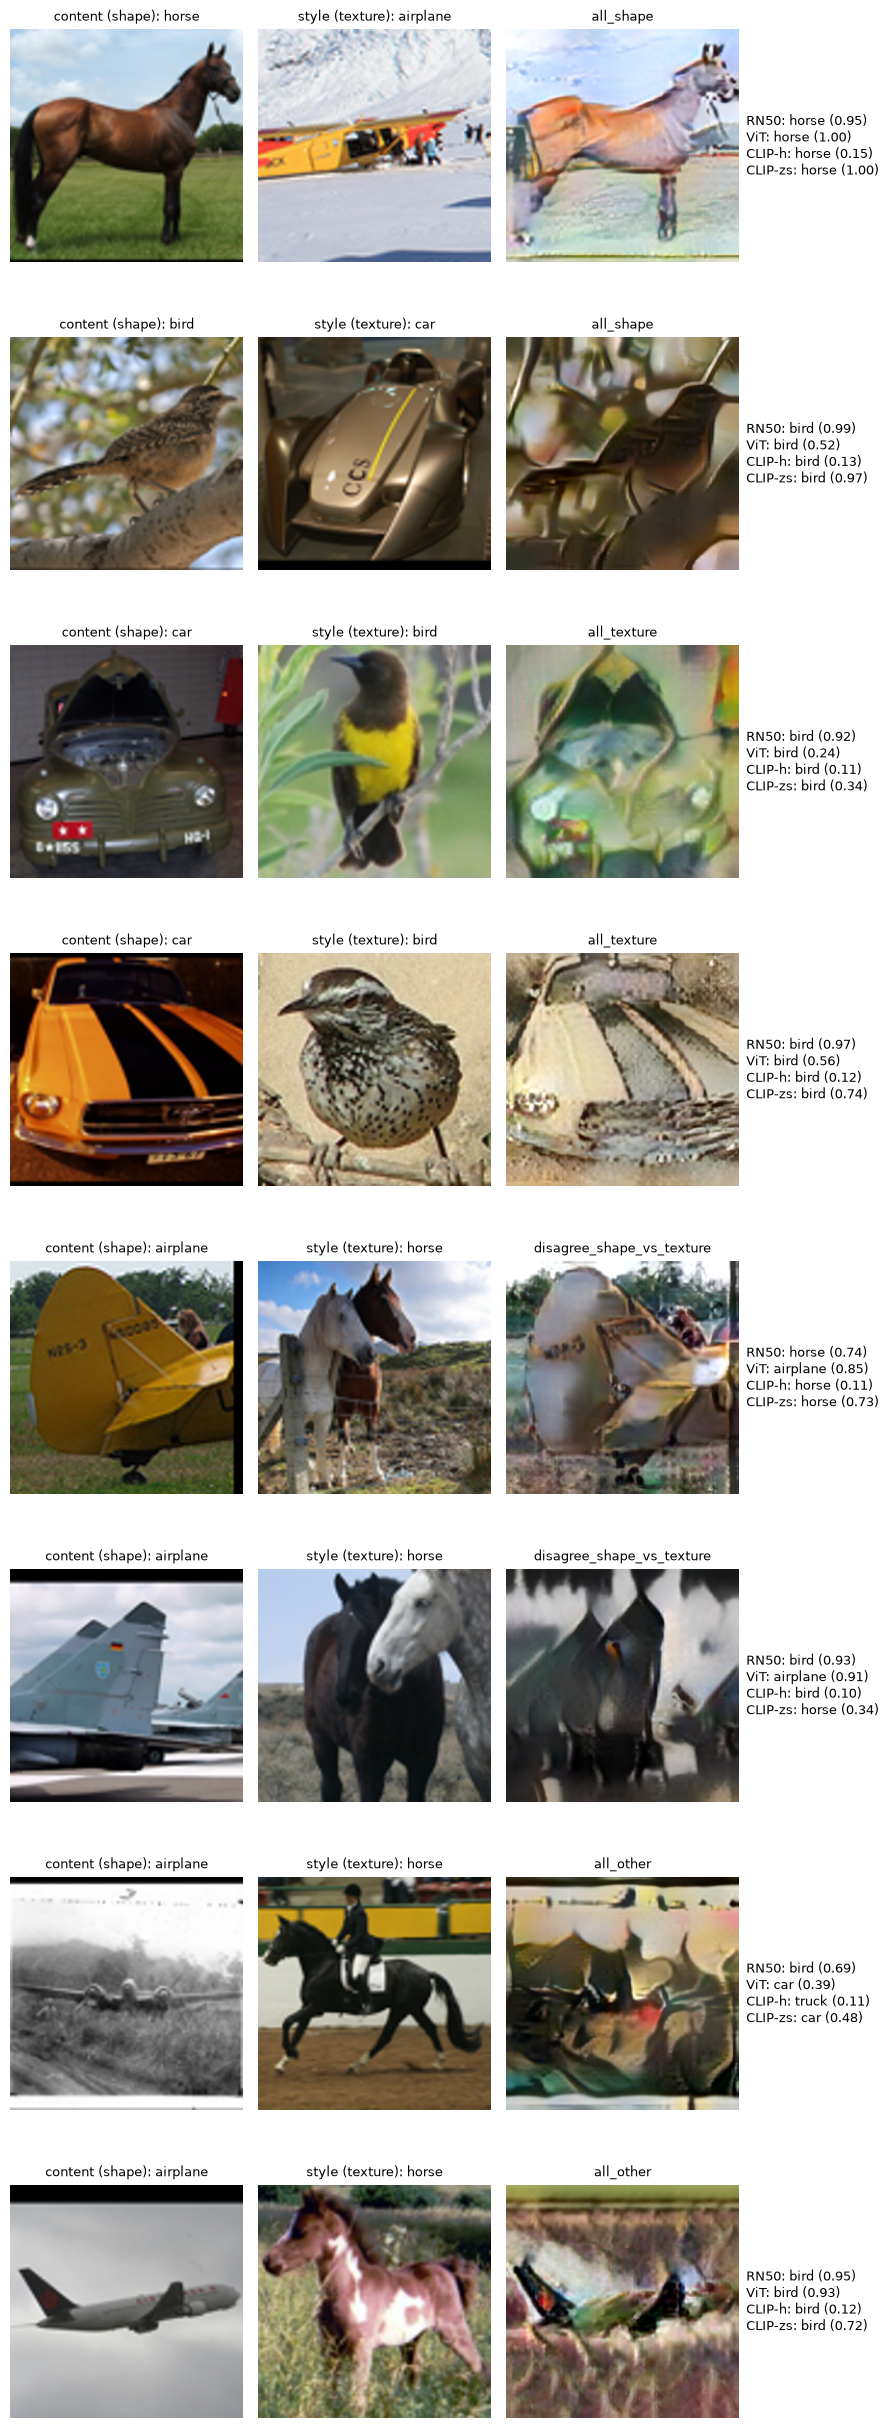

In [10]:
clean_imgs = torch.load(CACHE / "sets" / "clean.pt")["images"]
cc_imgs = torch.load(CACHE / "sets" / "cue_conflict.pt")["images"]
chosen = [(cat, i) for cat in ["all_shape", "all_texture", "disagree_shape_vs_texture", "all_other"]
          for i in ex.index[ex.category == cat][:2]]
short = {"resnet50_head": "RN50", "vit_b16_head": "ViT", "clip_head": "CLIP-h", "clip_zeroshot": "CLIP-zs"}
fig, axes = plt.subplots(len(chosen), 3, figsize=(9, 3.1 * len(chosen)))
axes = np.atleast_2d(axes)
for r, (cat, i) in enumerate(chosen):
    row = ex.loc[i]
    for c, (im, t) in enumerate([(clean_imgs[row.content_idx], f"content (shape): {row.shape_class}"),
                                 (clean_imgs[row.style_idx], f"style (texture): {row.texture_class}"),
                                 (cc_imgs[i], cat)]):
        axes[r, c].imshow(im.permute(1, 2, 0).numpy()); axes[r, c].axis("off"); axes[r, c].set_title(t, fontsize=9)
    axes[r, 2].text(1.03, .5, "\n".join(f"{short[s]}: {row[f'{s}_pred']} ({row[f'{s}_conf']:.2f})" for s in SYSTEMS),
                    transform=axes[r, 2].transAxes, va="center", fontsize=9)
plt.tight_layout(); savefig(fig, "task1_cue_conflict_examples"); plt.show()

## 6.4 t-SNE of clean + transformed features

One projection **per backbone**, fitted on the combined features of clean, grayscale, cue-conflict,
translate-right-32 and patch-shuffle images (settings from the config: perplexity, iterations, cosine
metric, PCA init, seed 6304). Each panel shares the same coordinates: clean points in the background,
one transformed condition highlighted. Coordinates are **not** comparable across backbones.

As a coordinate-free companion, we also report the fraction of transformed images whose nearest
**clean** neighbour (cosine, original feature space) has the same ground-truth class.

saved figure task1_representation_tsne_resnet50


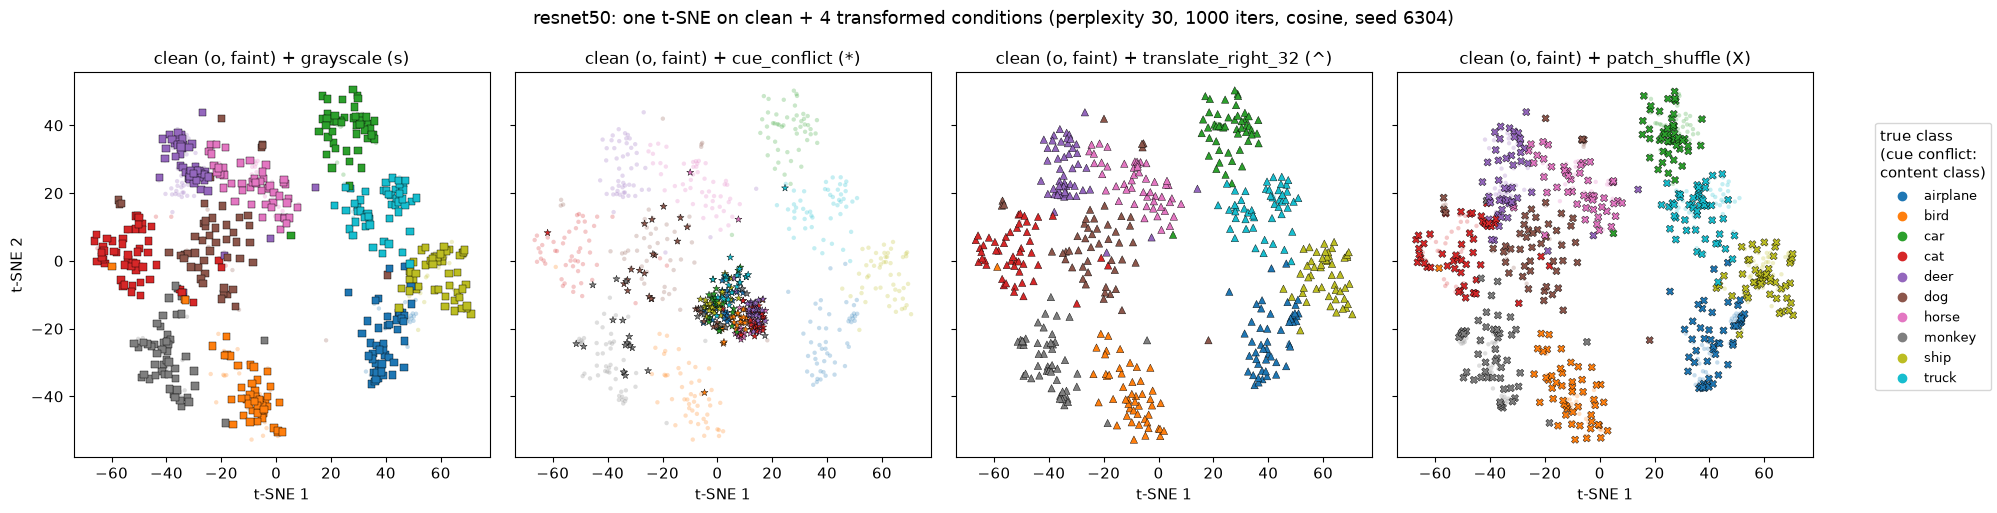

saved figure task1_representation_tsne_vit_b16


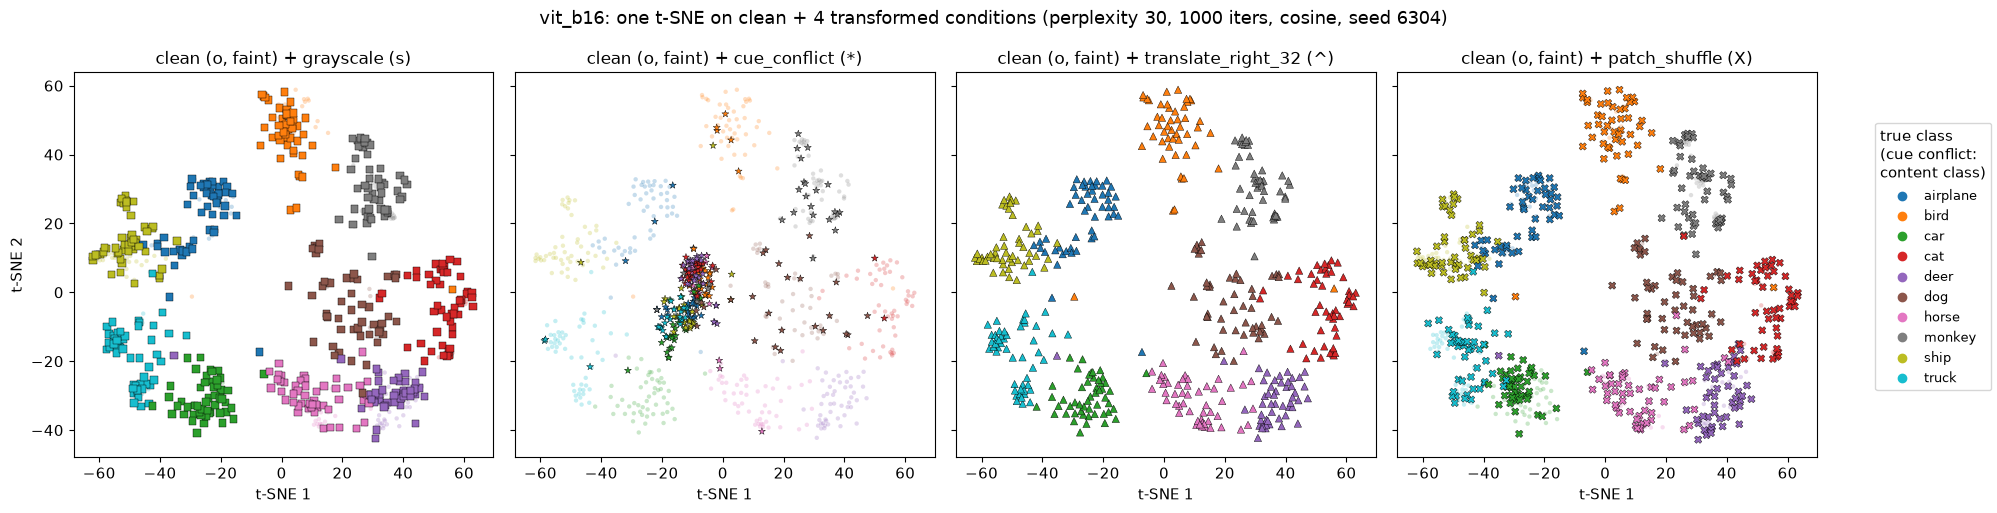

saved figure task1_representation_tsne_clip_vitb32


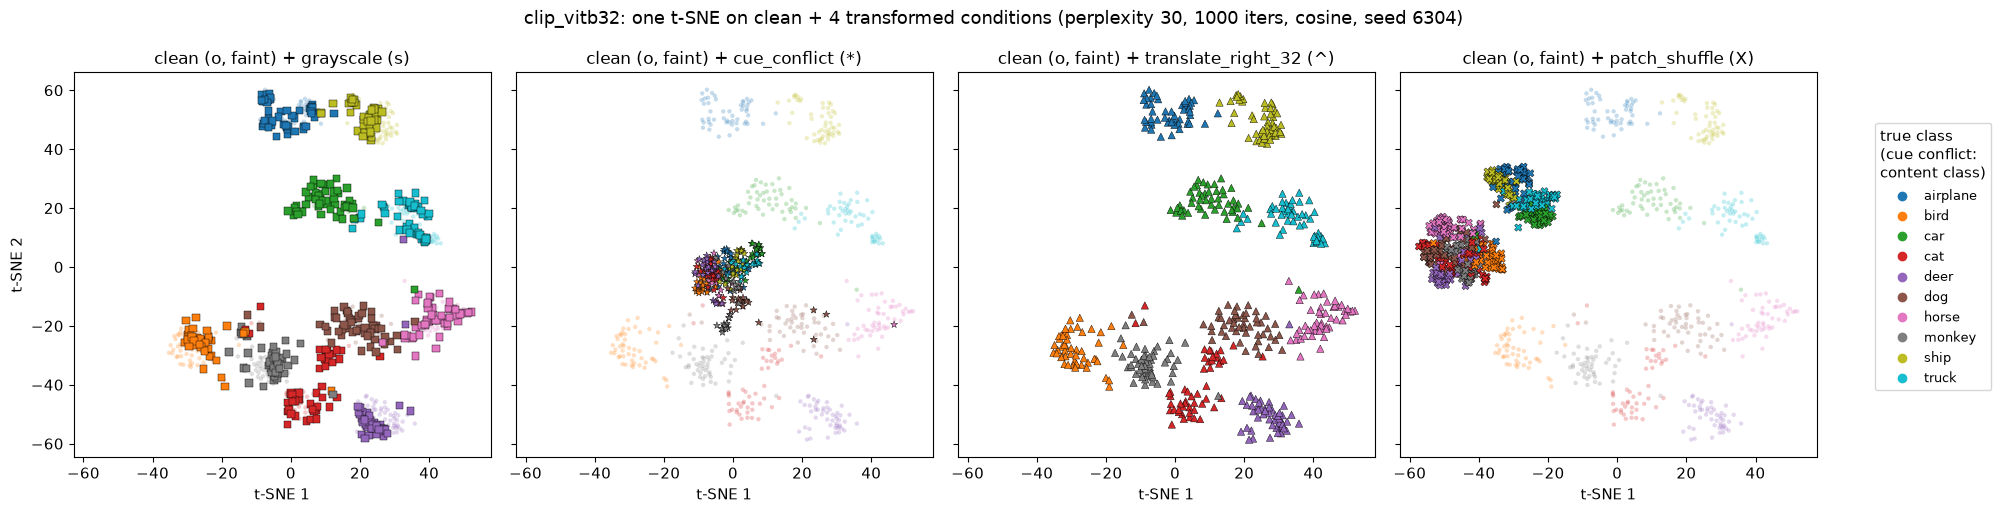

nearest_clean_same_class                   \
backbone                        clip_vitb32 resnet50 vit_b16   
condition                                                      
cue_conflict                          0.300     0.26   0.448   
grayscale                             0.986     0.99   0.998   
patch_shuffle                         0.702     1.00   0.998   
translate_right_32                    1.000     1.00   1.000   

                   nearest_clean_is_own_counterpart                   
backbone                                clip_vitb32 resnet50 vit_b16  
condition                                                             
cue_conflict                                  0.088    0.096   0.280  
grayscale                                     0.880    0.942   0.944  
patch_shuffle                                 0.308    0.974   0.978  
translate_right_32                            1.000    1.000   1.000

In [11]:
TS = CFG["tsne"]
MARKERS = {"grayscale": "s", "cue_conflict": "*", "translate_right_32": "^", "patch_shuffle": "X"}
CONDS = [("clean", "o")] + [(c, MARKERS[c]) for c in TS["transforms"]]      # conditions come from the config
cmap = plt.get_cmap("tab10")
nn_rows = []
for bb in BACKBONES:
    X = np.concatenate([FE[bb][c].numpy() for c, _ in CONDS])
    lab = np.concatenate([y if c != "cue_conflict" else cc["shape_label"].numpy() for c, _ in CONDS])
    cond = np.concatenate([[c] * len(FE[bb][c]) for c, _ in CONDS])
    emb = TSNE(n_components=2, perplexity=TS["perplexity"], max_iter=TS["n_iter"], metric=TS["metric"],
               init="pca", random_state=SEED).fit_transform(X)
    pd.DataFrame({"x": emb[:, 0], "y": emb[:, 1], "class": [CLASSES[k] for k in lab], "condition": cond}).to_csv(
        TAB / f"task1_tsne_coords_{bb}.csv", index=False)

    fig, axes = plt.subplots(1, 4, figsize=(20, 5.2), sharex=True, sharey=True)
    mc = cond == "clean"
    for ax, (c, mk) in zip(axes, CONDS[1:]):
        ax.scatter(emb[mc, 0], emb[mc, 1], c=[cmap(k) for k in lab[mc]], marker="o", s=10, alpha=.25, linewidths=0)
        m = cond == c
        ax.scatter(emb[m, 0], emb[m, 1], c=[cmap(k) for k in lab[m]], marker=mk, s=28, edgecolors="k", linewidths=.3)
        ax.set_title(f"clean (o, faint) + {c} ({mk})"); ax.set_xlabel("t-SNE 1")
    axes[0].set_ylabel("t-SNE 2")
    handles = [plt.Line2D([], [], marker="o", ls="", color=cmap(k), label=CLASSES[k]) for k in range(len(CLASSES))]
    fig.legend(handles=handles, loc="center right", title="true class\n(cue conflict:\ncontent class)")
    fig.suptitle(f"{bb}: one t-SNE on clean + 4 transformed conditions (perplexity {TS['perplexity']}, "
                 f"{TS['n_iter']} iters, {TS['metric']}, seed {SEED})")
    plt.tight_layout(rect=(0, 0, .92, 1)); savefig(fig, f"task1_representation_tsne_{bb}"); plt.show()

    # coordinate-free companion metric (original feature space)
    Fc = F.normalize(FE[bb]["clean"], dim=1)
    for c, _ in CONDS[1:]:
        nn_idx = (F.normalize(FE[bb][c], dim=1) @ Fc.T).argmax(1).numpy()
        true = y if c != "cue_conflict" else cc["shape_label"].numpy()
        nn_rows.append({"backbone": bb, "condition": c, "nearest_clean_same_class": float((y[nn_idx] == true).mean()),
                        "nearest_clean_is_own_counterpart": float((nn_idx == clean_ref(c)).mean())})
NN = pd.DataFrame(nn_rows)
NN.to_csv(TAB / "task1_clean_neighbour_agreement.csv", index=False)
NN.pivot(index="condition", columns="backbone", values=["nearest_clean_same_class", "nearest_clean_is_own_counterpart"]).round(3)